In [17]:
from tdc.single_pred import Tox
from rdkit import Chem, RDLogger
from rdkit.Chem import Lipinski, Descriptors, Crippen,rdMolDescriptors, GraphDescriptors, QED
from rdkit.Chem import Fragments, AllChem
from rdkit.Chem.rdMolDescriptors import (
    CalcTPSA, CalcKappa1, CalcKappa2, CalcKappa3,
    CalcChi0v, CalcChi1v, CalcChi2v, CalcChi3v, CalcChi4v,
    CalcChi0n, CalcChi1n, CalcChi2n, CalcChi3n, CalcChi4n,
)

RDLogger.DisableLog('rdApp.*')

from copy import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Optional GPU acceleration (RAPIDS)
GPU_AVAILABLE = False
GPU_BACKEND = 'CPU (scikit-learn)'
cp = None
cuPCA = None
try:
    import cupy as cp
    from cuml.decomposition import PCA as cuPCA
    GPU_AVAILABLE = True
    GPU_BACKEND = 'GPU (RAPIDS cuML)'
except Exception:
    pass

# Local utilities
import sys
sys.path.insert(0, '.')

random_state = 0

In [18]:
df = pd.read_csv('../data/processed/train.csv')
print(f'Compute backend: {GPU_BACKEND}')
if not GPU_AVAILABLE:
    print('GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.')

Compute backend: CPU (scikit-learn)
GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.


## Advanced Analysis: Outliers & Distributions

Top 20 features by outlier count (IQR):
                       IQR  Z-score (>3)
mordred_SsssCH        1790            57
mordred_MAXsssCH      1790            61
mordred_MINsssCH      1790            88
mordred_BCUTdv-1h     1659           115
VSA_EState9           1611            96
mordred_VSA_EState9   1611            96
mordred_BCUTv-1l      1419           206
mordred_AATS8se       1340             1
mordred_AATS8are      1307            12
mordred_BCUTp-1l      1299           205
mordred_AATS8pe       1296            11
mordred_PEOE_VSA11    1279           131
PEOE_VSA11            1279           131
mordred_AATS8i        1276             0
mordred_ETA_dAlpha_A  1273            85
mordred_MAXdssC       1260            81
mordred_BCUTs-1h      1241             0
mordred_MAXsOH        1237             0
mordred_SsOH          1237            84
mordred_NsOH          1237            71

Target (LD50) outliers (|z| > 3): 33


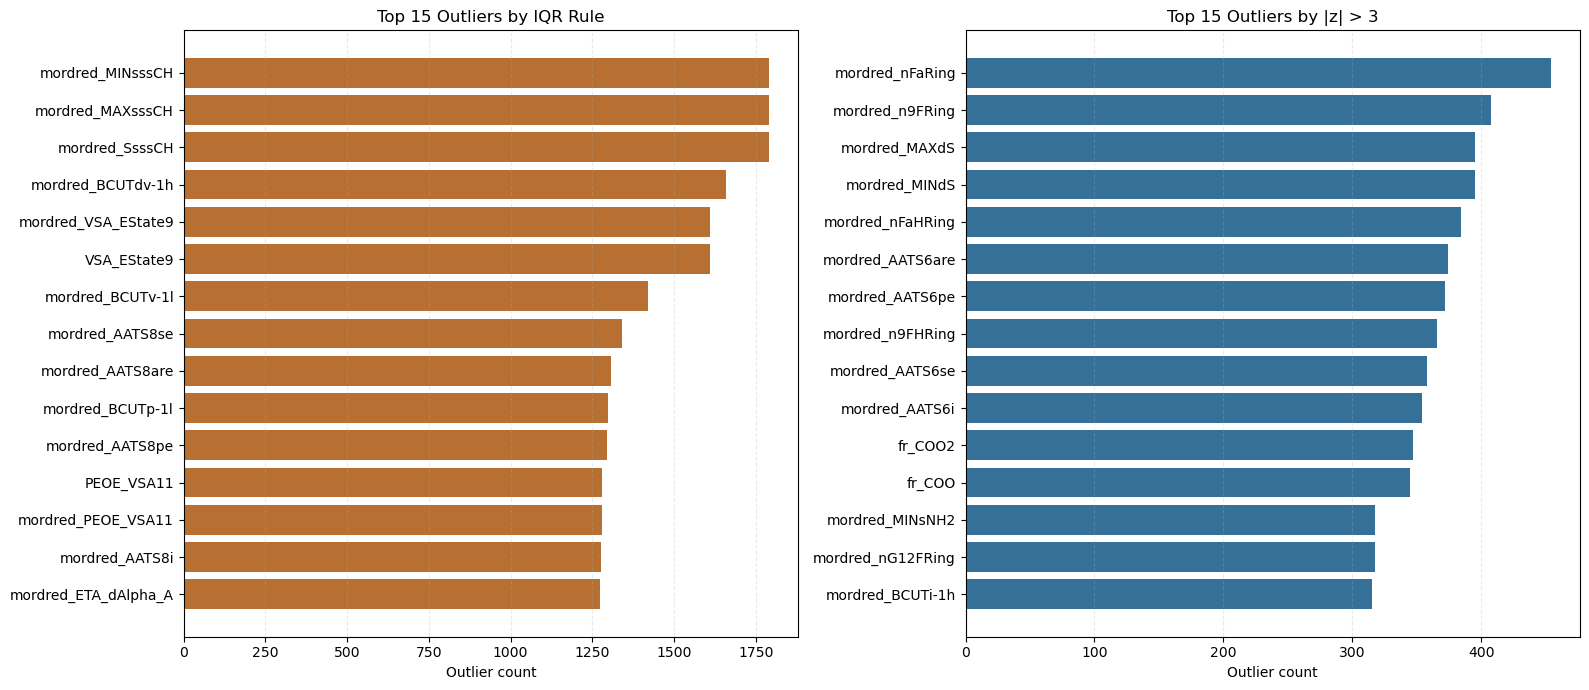

In [19]:
# Outlier detection
from scipy.stats import zscore

descriptor_cols = df.select_dtypes(include=[np.number]).columns.difference(['Y'])

outlier_summary = {}
for col in descriptor_cols:
    valid_data = df[col].dropna()

    # IQR method
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_outliers = ((valid_data < lower) | (valid_data > upper)).sum()

    # Z-score method (|z| > 3)
    z_scores = np.abs(zscore(valid_data))
    z_outliers = (z_scores > 3).sum()

    outlier_summary[col] = {'IQR': iqr_outliers, 'Z-score (>3)': z_outliers}

outlier_df = pd.DataFrame(outlier_summary).T
print('Top 20 features by outlier count (IQR):')
print(outlier_df.sort_values('IQR', ascending=False).head(20))
print(f"\nTarget (LD50) outliers (|z| > 3): {(np.abs(zscore(df['Y'])) > 3).sum()}")

# Visualization
top_n = 15
top_iqr = outlier_df.sort_values('IQR', ascending=False).head(top_n).sort_values('IQR')
top_z = outlier_df.sort_values('Z-score (>3)', ascending=False).head(top_n).sort_values('Z-score (>3)')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top_iqr.index, top_iqr['IQR'], color='#af601a', alpha=0.9)
axes[0].set_title(f'Top {top_n} Outliers by IQR Rule')
axes[0].set_xlabel('Outlier count')
axes[0].grid(alpha=0.25, axis='x', linestyle='--')

axes[1].barh(top_z.index, top_z['Z-score (>3)'], color='#1f618d', alpha=0.9)
axes[1].set_title(f'Top {top_n} Outliers by |z| > 3')
axes[1].set_xlabel('Outlier count')
axes[1].grid(alpha=0.25, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

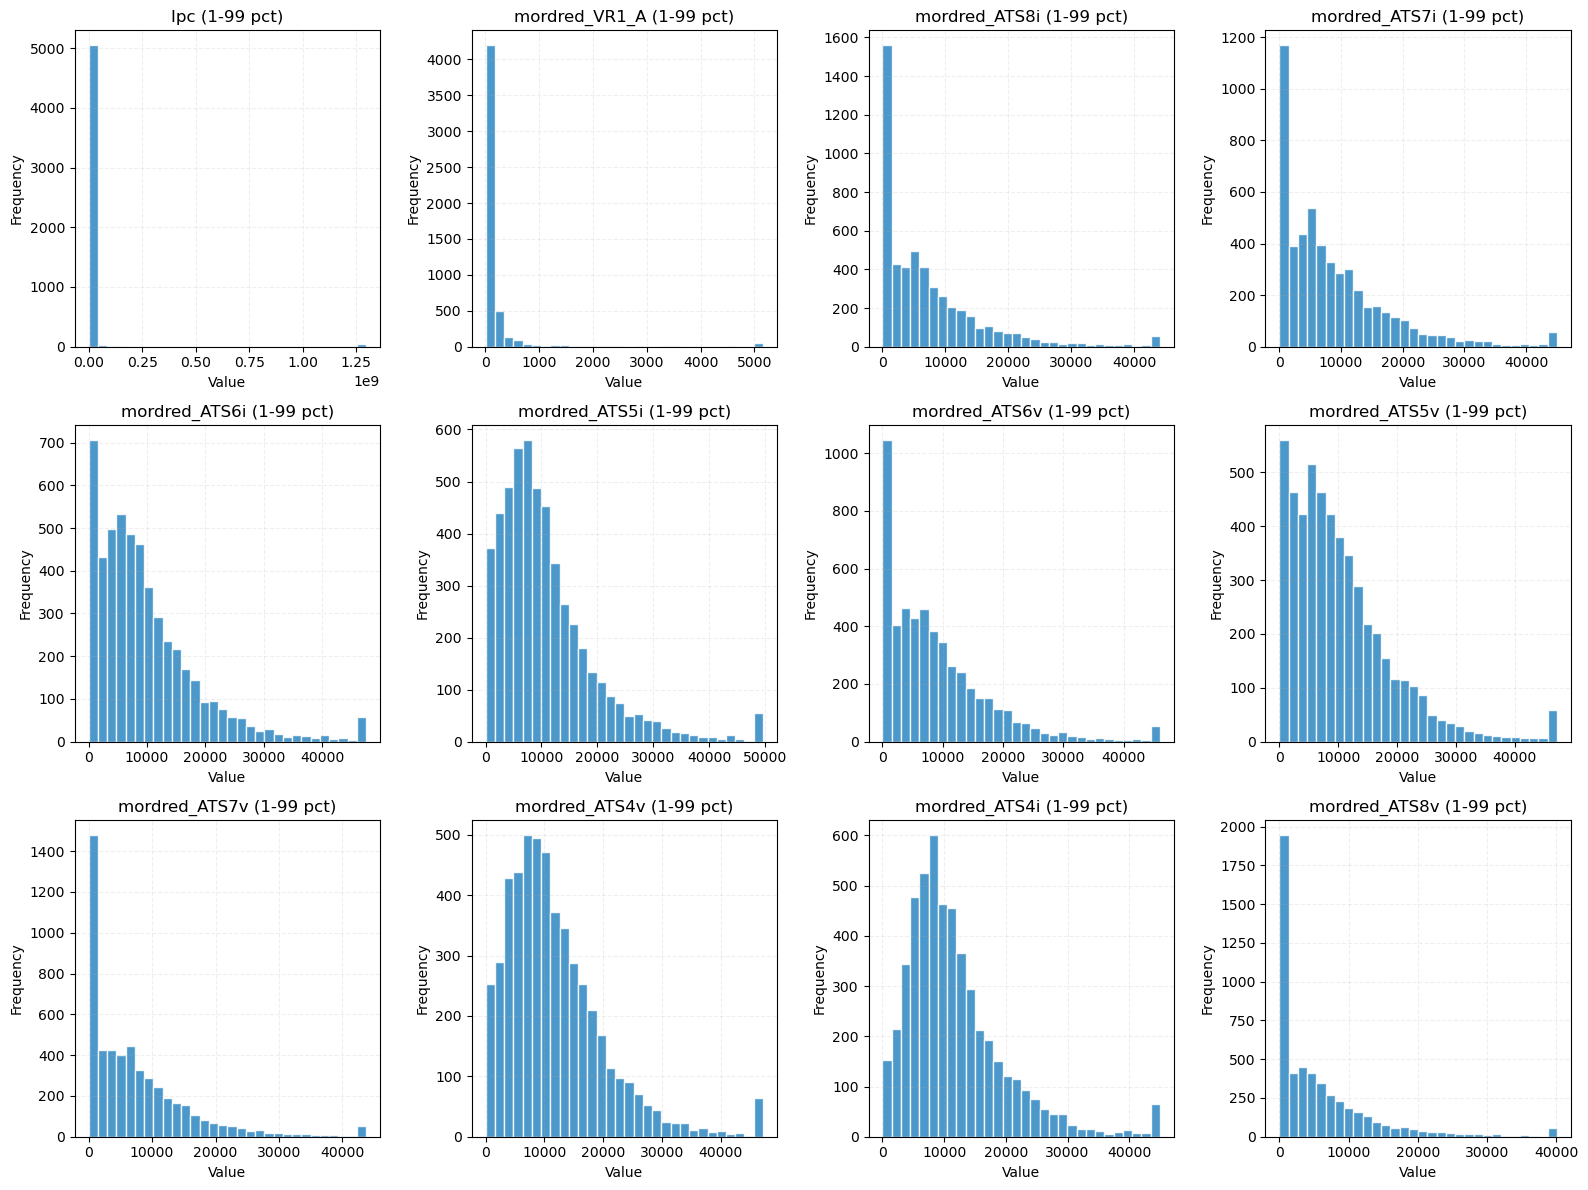


Descriptor summary (first 20 columns):
       BalabanJ   BertzCT      Chi0     Chi0n     Chi0v      Chi1     Chi1n  \
count  5170.000  5170.000  5170.000  5170.000  5170.000  5170.000  5170.000   
mean      2.686   403.844    12.090     9.479    10.319     7.728     5.289   
std       0.755   306.566     5.508     4.581     4.711     3.711     2.811   
min       0.826     2.000     2.000     1.115     1.115     1.000     0.289   
25%       2.162   173.713     8.268     6.436     6.968     5.151     3.430   
50%       2.627   355.187    11.380     8.827     9.702     7.254     4.826   
75%       3.070   558.558    14.789    11.617    12.894     9.577     6.523   
max       7.294  3416.975    66.977    56.065    56.065    42.102    30.562   

          Chi1v     Chi2n     Chi2v     Chi3n     Chi3v     Chi4n     Chi4v  \
count  5170.000  5170.000  5170.000  5170.000  5170.000  5170.000  5170.000   
mean      6.141     3.845     4.940     2.502     3.396     1.645     2.307   
std       3

In [20]:
# Feature distributions (readable histograms, clipped to 1st-99th percentile)
max_plots = 12
plot_cols = df[descriptor_cols].var().sort_values(ascending=False).head(max_plots).index.tolist()
n_rows, n_cols = 3, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(plot_cols):
    valid_data = df[col].dropna()
    low_q, high_q = np.percentile(valid_data, [1, 99])
    clipped = valid_data.clip(lower=low_q, upper=high_q)

    axes[idx].hist(clipped, bins=30, color='#2e86c1', alpha=0.85, edgecolor='white')
    axes[idx].set_title(f'{col} (1-99 pct)')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.2, linestyle='--')

for idx in range(len(plot_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Summary statistics
print('\nDescriptor summary (first 20 columns):')
print(df[descriptor_cols].describe().round(3).iloc[:, :20])

Top 20 features by |CV|:
                      Mean    Std     CV (%)     Min     Max   Range
mordred_MATS8dv     -0.001  0.366 -42027.981  -2.449   3.690   6.139
mordred_ATSC3c      -0.001  0.254 -40956.279  -1.844   3.665   5.509
mordred_MATS8m      -0.002  0.384 -25139.119  -3.734   2.821   6.555
mordred_MATS8Z      -0.002  0.382 -23307.533  -3.724   2.835   6.559
mordred_AATSC8s     -0.007  1.508 -23145.018 -11.144  20.724  31.869
mordred_SssssN      -0.000  0.020 -15160.892  -0.517   0.856   1.373
mordred_MINssssN    -0.000  0.020 -15160.892  -0.517   0.856   1.373
mordred_MAXssssN    -0.000  0.020 -15160.892  -0.517   0.856   1.373
mordred_MATS5c      -0.002  0.212 -14130.412  -1.910   3.979   5.889
VSA_EState5         -0.018  2.518 -13726.495 -81.749   9.498  91.247
mordred_VSA_EState5 -0.018  2.518 -13726.495 -81.749   9.498  91.247
mordred_MATS6i      -0.002  0.248 -11602.634  -1.558   2.036   3.594
mordred_AATSC5c     -0.000  0.006  -8183.497  -0.109   0.095   0.204
mordred_n

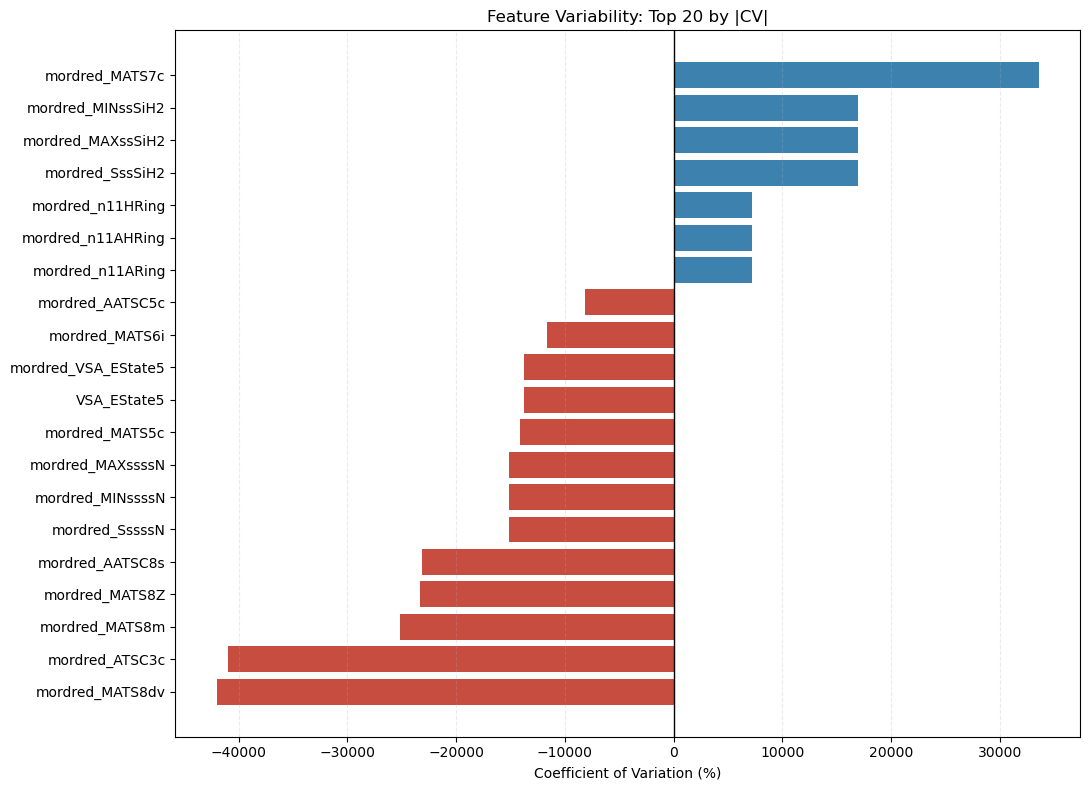

In [21]:
# Feature variability: Coefficient of Variation
cv_analysis = {}
for col in descriptor_cols:
    valid_data = df[col].dropna()
    mean_val = valid_data.mean()
    std_val = valid_data.std()
    cv = (std_val / mean_val) * 100 if mean_val != 0 else np.nan
    cv_analysis[col] = {
        'Mean': mean_val,
        'Std': std_val,
        'CV (%)': cv,
        'Min': valid_data.min(),
        'Max': valid_data.max(),
        'Range': valid_data.max() - valid_data.min()
    }

cv_df = pd.DataFrame(cv_analysis).T
cv_plot_df = cv_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['CV (%)']).copy()
cv_plot_df['Abs_CV'] = cv_plot_df['CV (%)'].abs()

top_n = 20
top_cv = cv_plot_df.nlargest(top_n, 'Abs_CV').sort_values('CV (%)')

print('Top 20 features by |CV|:')
print(top_cv[['Mean', 'Std', 'CV (%)', 'Min', 'Max', 'Range']].round(3))

# Visualization: only top |CV| features
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    top_cv.index,
    top_cv['CV (%)'],
    color=['#c0392b' if x < 0 else '#2874a6' for x in top_cv['CV (%)']],
    alpha=0.9
)
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title(f'Feature Variability: Top {top_n} by |CV|')
ax.axvline(0, color='black', linewidth=1)
ax.grid(alpha=0.25, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

In [22]:
# Prepare data for PCA
X = df[descriptor_cols].fillna(df[descriptor_cols].mean())
y = df['Y']

PCA refit without dominant feature: Ipc


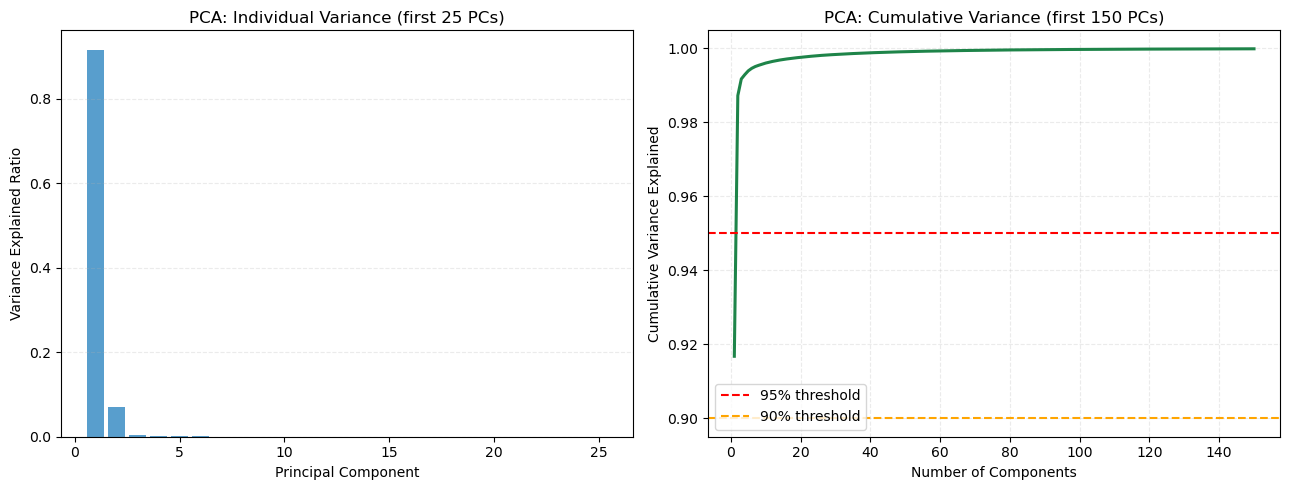

Components needed for 95% variance: 2/1810
Variance explained by first 3 PCs: 0.992


In [26]:
# PCA: Dimensionality reduction & variance analysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

# Standardize data
scaler = RobustScaler()
pca_feature_names = X.columns.copy()
X_pca_input = X.copy()
X_scaled = scaler.fit_transform(X_pca_input)

def fit_pca(x_scaled):
    if GPU_AVAILABLE and cuPCA is not None:
        x_gpu = cp.asarray(x_scaled, dtype=cp.float32)
        pca_model = cuPCA()
        pca_model.fit(x_gpu)
        return pca_model, cp.asnumpy(pca_model.explained_variance_ratio_)
    pca_model = PCA()
    pca_model.fit(x_scaled)
    return pca_model, pca_model.explained_variance_ratio_

pca, explained_var_ratio = fit_pca(X_scaled)

# If one feature dominates almost all variance, refit without dominant variance feature for readable PCA plots
if float(explained_var_ratio[0]) > 0.95 and X.shape[1] > 2:
    dominant_feature = X.var().idxmax()
    pca_feature_names = X.columns.difference([dominant_feature])
    X_pca_input = X[pca_feature_names]
    X_scaled = scaler.fit_transform(X_pca_input)
    pca, explained_var_ratio = fit_pca(X_scaled)
    print(f'PCA refit without dominant feature: {dominant_feature}')

# Plot variance explained (limited components for readability)
cumsum_var = np.cumsum(explained_var_ratio)
n_show = min(25, len(explained_var_ratio))
n_cum = min(150, len(cumsum_var))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual variance (first n_show PCs)
axes[0].bar(range(1, n_show + 1), explained_var_ratio[:n_show], alpha=0.8, color='#2e86c1')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title(f'PCA: Individual Variance (first {n_show} PCs)')
axes[0].grid(alpha=0.25, axis='y', linestyle='--')

# Cumulative variance (first n_cum PCs)
axes[1].plot(range(1, n_cum + 1), cumsum_var[:n_cum], linewidth=2.2, color='#1e8449')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title(f'PCA: Cumulative Variance (first {n_cum} PCs)')
axes[1].legend()
axes[1].grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

# Components needed for 95% variance
n_comps_95 = int(np.argmax(cumsum_var >= 0.95) + 1)
idx_3 = min(2, len(cumsum_var) - 1)
print(f'Components needed for 95% variance: {n_comps_95}/{len(explained_var_ratio)}')
print(f'Variance explained by first 3 PCs: {cumsum_var[idx_3]:.3f}')

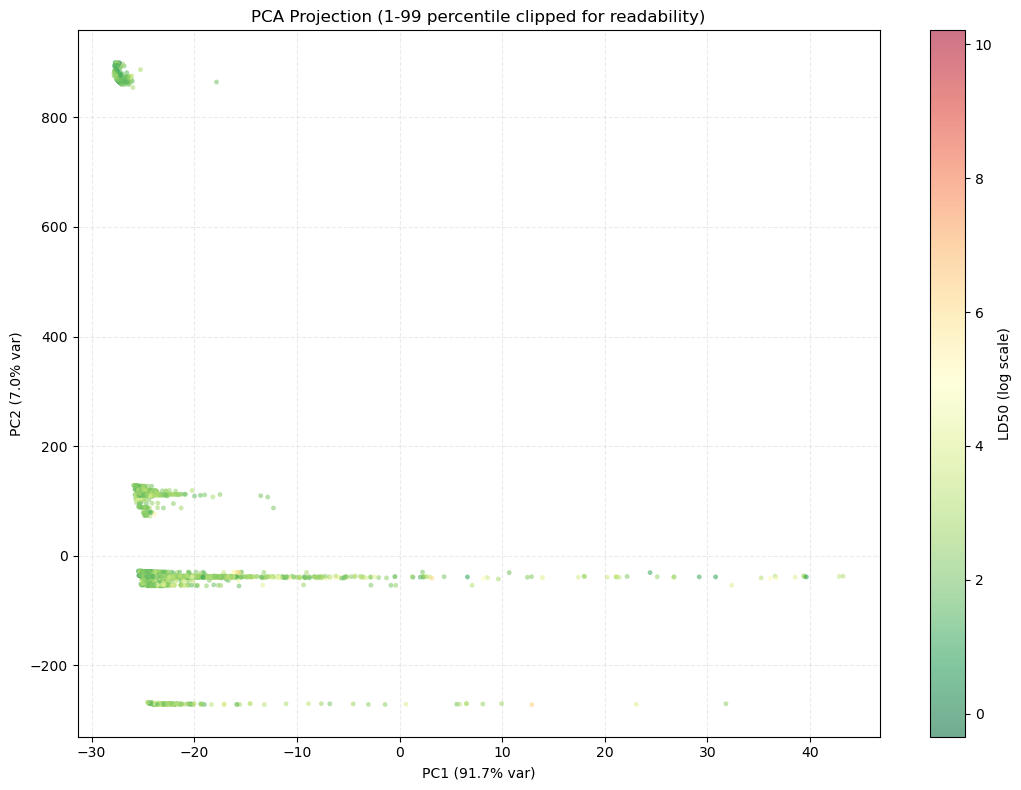


Top loading features for PC1/PC2:
                       PC1    PC2
mordred_VR1_A        0.768  0.002
mordred_VR2_A        0.640  0.003
mordred_BCUTv-1l    -0.003  0.987
mordred_BCUTdv-1h    0.001 -0.149
mordred_GGI10        0.000 -0.003
mordred_WPath        0.000 -0.001
mordred_SpDiam_Dzm   0.000 -0.001
mordred_SpDiam_DzZ   0.000 -0.001
fr_unbrch_alkane     0.000  0.000
mordred_SpDiam_Dzse  0.000 -0.001
mordred_BCUTare-1h   0.000 -0.029
mordred_AATS7i       0.000 -0.007
mordred_BCUTpe-1h    0.000 -0.019
mordred_BCUTp-1l    -0.000  0.021
mordred_BCUTse-1h    0.000 -0.017
mordred_SsF          0.000 -0.017
mordred_PEOE_VSA5   -0.000  0.007
PEOE_VSA5           -0.000  0.007


In [27]:
# 2D PCA projection: Molecules by toxicity
# Use first 2 PCs
if GPU_AVAILABLE and cuPCA is not None:
    X_pca_full = pca.transform(cp.asarray(X_scaled, dtype=cp.float32))
    X_pca_2d = cp.asnumpy(X_pca_full)[:, :2]
    explained_1 = float(explained_var_ratio[0])
    explained_2 = float(explained_var_ratio[1])
    loadings = cp.asnumpy(pca.components_[:2, :]).T
else:
    X_pca_2d = pca.transform(X_scaled)[:, :2]
    explained_1 = float(explained_var_ratio[0])
    explained_2 = float(explained_var_ratio[1])
    loadings = pca.components_[:2, :].T

# Clip to 1st-99th percentile for a readable plot
pc_df = pd.DataFrame({'PC1': X_pca_2d[:, 0], 'PC2': X_pca_2d[:, 1], 'Y': y.values})
pc1_low, pc1_high = np.percentile(pc_df['PC1'], [1, 99])
pc2_low, pc2_high = np.percentile(pc_df['PC2'], [1, 99])
vis_df = pc_df[
    (pc_df['PC1'] >= pc1_low) & (pc_df['PC1'] <= pc1_high) &
    (pc_df['PC2'] >= pc2_low) & (pc_df['PC2'] <= pc2_high)
]

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    vis_df['PC1'],
    vis_df['PC2'],
    c=vis_df['Y'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.55,
    edgecolors='none'
 )
ax.set_xlabel(f'PC1 ({explained_1:.1%} var)')
ax.set_ylabel(f'PC2 ({explained_2:.1%} var)')
ax.set_title('PCA Projection (1-99 percentile clipped for readability)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('LD50 (log scale)')
ax.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

# Feature loading: top contributors only
loading_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=pca_feature_names)
top_pc1 = loading_df['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = loading_df['PC2'].abs().sort_values(ascending=False).head(10)
top_loadings = loading_df.loc[top_pc1.index.union(top_pc2.index)].copy()

print('\nTop loading features for PC1/PC2:')
print(top_loadings.sort_values('PC1', key=np.abs, ascending=False).round(3))

ANOVA top 20 most significant features (smallest p-values):
                 F-statistic        p-value
mordred_MIC1      443.927774  1.220205e-178
mordred_ATS1m     412.901044  4.411919e-167
mordred_MIC2      411.853808  1.088510e-166
mordred_SM1_DzZ   402.891429  2.506072e-163
mordred_SM1_Dzm   402.757122  2.814843e-163
mordred_ATS1Z     377.034429  1.431782e-153
mordred_ATS2m     366.656707  1.246789e-149
mordred_Xp-3dv    364.533289  8.010495e-149
Chi3v             364.372783  9.220374e-149
mordred_ATS2Z     363.222302  2.527683e-148
mordred_IC0       347.315109  2.992154e-142
mordred_MIC3      345.370233  1.662590e-141
mordred_MID_h     341.621878  4.546060e-140
mordred_MIC4      328.738380  4.076814e-135
mordred_Xp-2dv    328.083251  7.290399e-135
mordred_GATS1m    327.567707  1.151960e-134
Chi2v             327.346376  1.401998e-134
mordred_GATS1Z    327.084877  1.768268e-134
mordred_MIC5      325.960324  4.798826e-134
NumHeteroatoms    321.965556  1.670051e-132

Significant fea

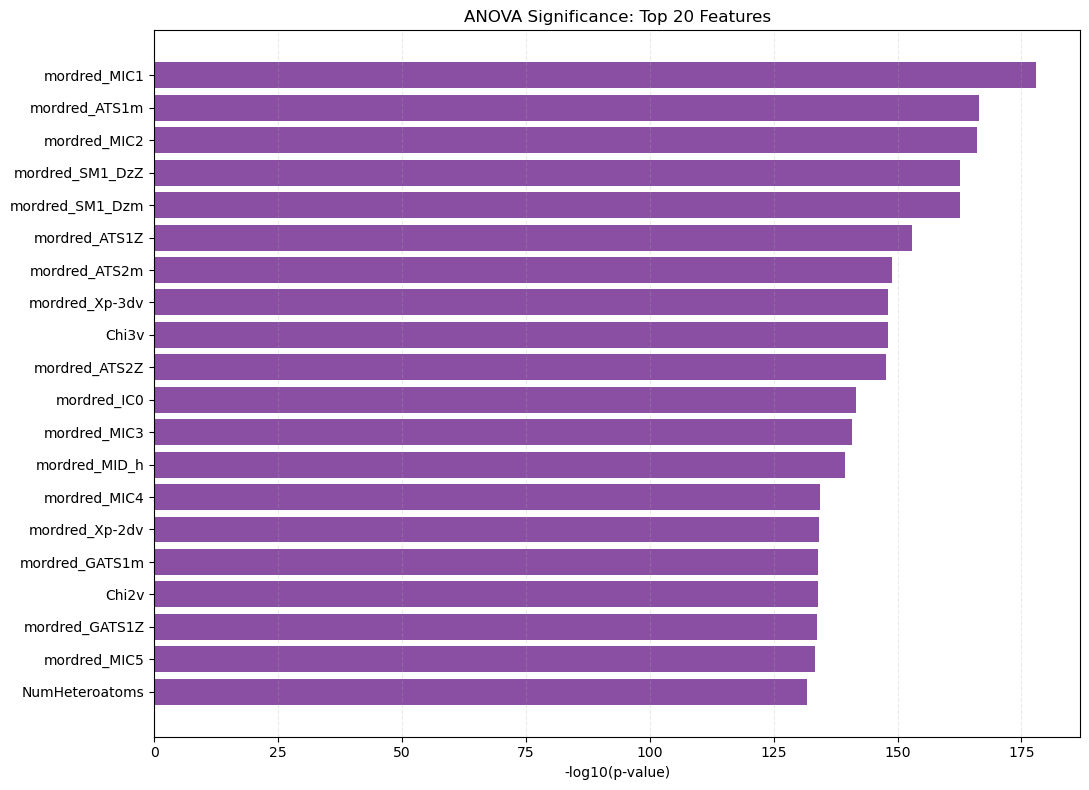

In [25]:
# ANOVA: Significance of features across toxicity groups
from scipy.stats import f_oneway, pearsonr

# Discretize target into 3 toxicity groups (low, medium, high)
y_groups = pd.qcut(df['Y'], q=3, labels=['Low', 'Medium', 'High'])

anova_results = {}
for col in descriptor_cols:
    valid_mask = df[col].notna()
    groups = [df[col][valid_mask & (y_groups == g)].values for g in ['Low', 'Medium', 'High']]

    # Remove empty groups
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = {'F-statistic': f_stat, 'p-value': p_val}

anova_df = pd.DataFrame(anova_results).T.sort_values('p-value', ascending=True)
significant = anova_df[anova_df['p-value'] < 0.05].copy()

print('ANOVA top 20 most significant features (smallest p-values):')
print(anova_df.head(20))
print(f"\nSignificant features (p < 0.05): {significant.shape[0]}")

if significant.shape[0] > 0:
    top_n = min(20, significant.shape[0])
    plot_df = significant.head(top_n).copy()
    plot_df['neg_log10_p'] = -np.log10(plot_df['p-value'].clip(lower=1e-300))
    plot_df = plot_df.sort_values('neg_log10_p')

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(plot_df.index, plot_df['neg_log10_p'], color='#7d3c98', alpha=0.9)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title(f'ANOVA Significance: Top {top_n} Features')
    ax.grid(alpha=0.25, axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()

---
**Analisi esplorativa completata.** Dataset pronto per feature selection e modellazione.